# Development of a CNN Model with the MFCC as it's input feature:

## Imports:

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2025-09-25 16:12:55.999467: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-25 16:12:56.007209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758827576.015959   72636 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758827576.018500   72636 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758827576.025803   72636 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Geral:

In [3]:
BATCH_SIZE = 32
SAMPLE_RATE = 16000 # Taxa de amostragem comum para fala
AUDIO_DURATION_S = 1 # Duração de cada áudio em segundos
SAMPLES_PER_AUDIO = SAMPLE_RATE * AUDIO_DURATION_S

# Parâmetros para STFT
FRAME_LENGTH = 512
FRAME_STEP = 256
N_FFT = 512

# Parâmetros para Mel & MFCC
N_MELS = 128
F_MIN = 20
F_MAX = SAMPLE_RATE / 2
N_MFCCS = 40  # <--- MUDANÇA: Número de coeficientes MFCC a serem extraídos

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
def get_label(file_path: tf.Tensor) -> tf.Tensor:
    """Extrai o rótulo (label) como um inteiro a partir do caminho do arquivo."""
    parts = tf.strings.split(file_path, '/')
    label_str = parts[-2]
    label_int = tf.argmax(label_str == CLASS_NAMES)
    return tf.cast(label_int, tf.int64)

def decode_audio(file_path: tf.Tensor) -> tf.Tensor:
    """Lê, decodifica, normaliza e garante o comprimento fixo do áudio."""
    audio_binary = tf.io.read_file(file_path)
    audio, sr = tf.audio.decode_wav(audio_binary, desired_channels=1)
    waveform = tf.squeeze(audio, axis=-1)
    waveform = tf.cast(waveform, tf.float32)
    current_len = tf.shape(waveform)[0]

    if current_len < SAMPLES_PER_AUDIO:
        padding = tf.zeros(SAMPLES_PER_AUDIO - current_len, dtype=tf.float32)
        waveform = tf.concat([waveform, padding], 0)
    
    waveform = waveform[:SAMPLES_PER_AUDIO]
    waveform.set_shape([SAMPLES_PER_AUDIO])
    return waveform

# <--- MUDANÇA: Nova função para extrair MFCCs ---
def get_mfccs(waveform: tf.Tensor) -> tf.Tensor:
    """Converte a forma de onda (waveform) de áudio em MFCCs."""
    # 1. Primeiro, calculamos o log-mel espectrograma, que é a base para os MFCCs.
    stft = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=N_FFT
    )
    spectrogram = tf.abs(stft)
    mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=stft.shape[-1],
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=F_MIN,
        upper_edge_hertz=F_MAX
    )
    mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    # 2. Agora, calculamos os MFCCs a partir do log-mel espectrograma.
    # A função do TensorFlow já aplica a DCT (Transformada Discreta de Cosseno).
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)

    # 3. Mantemos apenas os primeiros N_MFCCS coeficientes, que são os mais informativos.
    mfccs = mfccs[..., :N_MFCCS]
    
    # 4. Adiciona uma dimensão de "canal" para compatibilidade com CNNs.
    # O formato final será (tempo, n_mfccs, canais=1)
    return tf.expand_dims(mfccs, axis=-1)


def process_path(file_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """Função principal que combina todas as etapas de processamento."""
    label = get_label(file_path)
    waveform = decode_audio(file_path)
    # <--- MUDANÇA: Chamando a nova função get_mfccs ---
    mfccs = get_mfccs(waveform)
    return mfccs, label

# --- 4. Função para Criar o Dataset Final ---

def create_dataset(data_path: Path, shuffle: bool = True):
    """Cria um tf.data.Dataset otimizado a partir de um diretório."""
    ds = tf.data.Dataset.list_files(str(data_path / '*/*.wav'), shuffle=shuffle)
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

## No Data Augmentation:

In [5]:
DATA_DIR = Path('../dataset')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'

CLASS_NAMES = np.array(sorted([item.name for item in TRAIN_DIR.glob('*') if item.is_dir()]))
print(f"Classes encontradas: {CLASS_NAMES}")

print("\nCriando o dataset de treinamento...")
train_ds = create_dataset(TRAIN_DIR, shuffle=True)

print("Criando o dataset de validação...")
val_ds = create_dataset(VALID_DIR, shuffle=False)

print("Criando o dataset de teste...")
test_ds = create_dataset(TEST_DIR, shuffle=False)

Classes encontradas: ['_silence_' '_unknown_' 'go' 'no' 'off' 'on' 'stop']

Criando o dataset de treinamento...


I0000 00:00:1758809961.349607   59397 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1239 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Criando o dataset de validação...
Criando o dataset de teste...


In [6]:
print("\n--- Verificação do Pipeline ---")
# <--- MUDANÇA: Atualizando variáveis e textos para MFCCs ---
for mfccs, labels in train_ds.take(1):
    print(f"Shape do lote de MFCCs: {mfccs.shape}")
    print(f"Shape do lote de labels: {labels.shape}")
    print(f"Tipo de dado dos MFCCs: {mfccs.dtype}")
    print(f"Tipo de dado dos labels: {labels.dtype}")
    
    first_mfcc = mfccs[0]
    print(f"Shape de um único MFCC: {first_mfcc.shape}")
    
    first_label = labels[0]
    print(f"Label do primeiro item do lote: {first_label.numpy()} ({CLASS_NAMES[first_label]})")



--- Verificação do Pipeline ---
Shape do lote de MFCCs: (32, 61, 40, 1)
Shape do lote de labels: (32,)
Tipo de dado dos MFCCs: <dtype: 'float32'>
Tipo de dado dos labels: <dtype: 'int64'>
Shape de um único MFCC: (61, 40, 1)
Label do primeiro item do lote: 3 (no)


2025-09-25 11:19:22.072700: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-25 11:19:22.075191: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Formato (shape) do lote de MFCCs: (32, 61, 40, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-25 11:19:22.200626: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


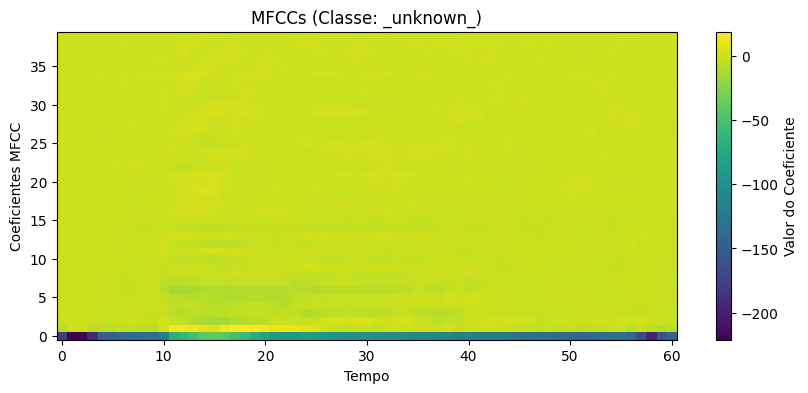

In [7]:
for mfccs, labels in train_ds.take(1):
    input_shape = mfccs.shape[1:]
    print(f"\nFormato (shape) do lote de MFCCs: {mfccs.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    # Não aplicamos mais o log aqui, pois os MFCCs já estão processados.
    plt.imshow(mfccs[0, :, :, 0].numpy().T, aspect='auto', origin='lower')
    plt.title(f"MFCCs (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Coeficientes MFCC")
    plt.xlabel("Tempo")
    plt.colorbar(label='Valor do Coeficiente')
    plt.show()
    break

### Training:

In [8]:
model_mfcc = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax') # Usar len(CLASS_NAMES) é mais robusto
])

model_mfcc.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 61, 40, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 61, 40, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 61, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,923 (4.94 MB)

 Trainable params: 1,293,641 (4.93 MB)

 Non-trainable params: 1,282 (5.01 KB)

In [9]:
model_mfcc.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [11]:
history = model_mfcc.fit(train_ds, validation_data=val_ds, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100


I0000 00:00:1758809963.673764   59524 service.cc:152] XLA service 0x73ca280054e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758809963.673780   59524 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-25 11:19:23.711287: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758809963.934801   59524 cuda_dnn.cc:529] Loaded cuDNN version 91002


 53/601 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2393 - loss: 2.3626

I0000 00:00:1758809965.922087   59524 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


601/601 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6313 - loss: 1.0685 - val_accuracy: 0.7545 - val_loss: 0.6693
Epoch 2/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8159 - loss: 0.5313 - val_accuracy: 0.7658 - val_loss: 0.6761
Epoch 3/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8739 - loss: 0.3655 - val_accuracy: 0.8783 - val_loss: 0.3582
Epoch 4/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8993 - loss: 0.2894 - val_accuracy: 0.8724 - val_loss: 0.4044
Epoch 5/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9173 - loss: 0.2441 - val_accuracy: 0.6182 - val_loss: 1.2877
Epoch 6/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9297 - loss: 0.2003 - val_accuracy: 0.8381 - val_loss: 0.5235
Epoch 7/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9349 - loss: 0.1867 - val_accuracy: 0.8783 - val_loss: 0.4590
Epoch 8/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9477 - loss: 0.1521 - val_accuracy: 0.8871

### Testing:

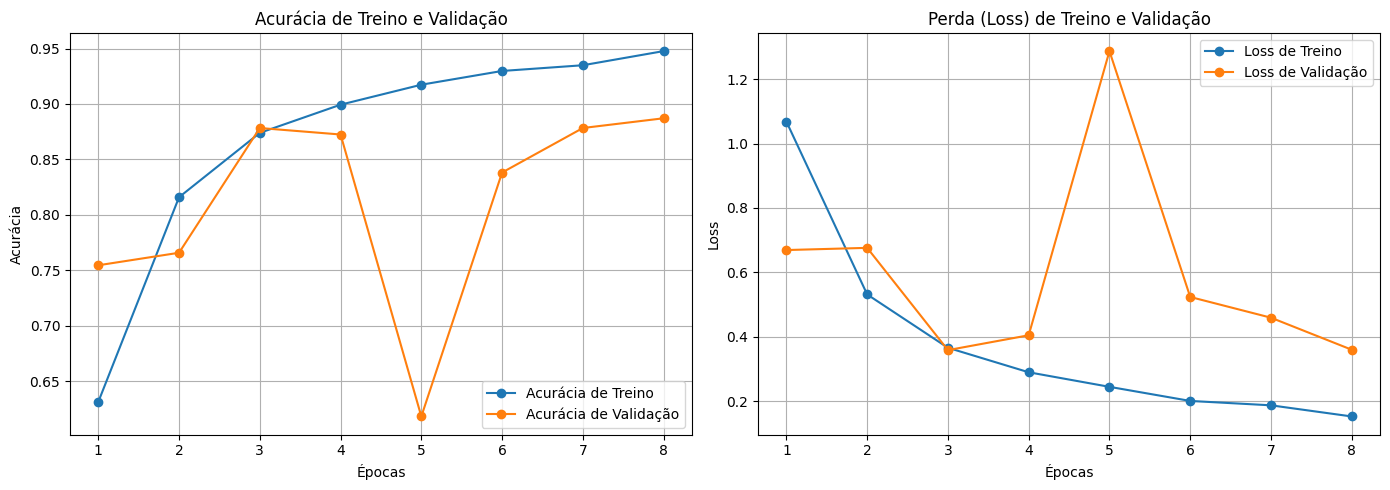

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [13]:
y_pred_probs = model_mfcc.predict(test_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       1.00      0.85      0.92       408
   _unknown_       0.79      0.70      0.74       466
          go       0.89      0.84      0.87       402
          no       0.78      0.97      0.86       405
         off       0.89      0.84      0.87       402
          on       0.84      0.91      0.87       396
        stop       0.88      0.94      0.91       411

    accuracy                           0.86      2890
   macro avg       0.87      0.86      0.86      2890
weighted avg       0.87      0.86      0.86      2890



2025-09-25 11:19:42.190254: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- Matriz de Confusão ---


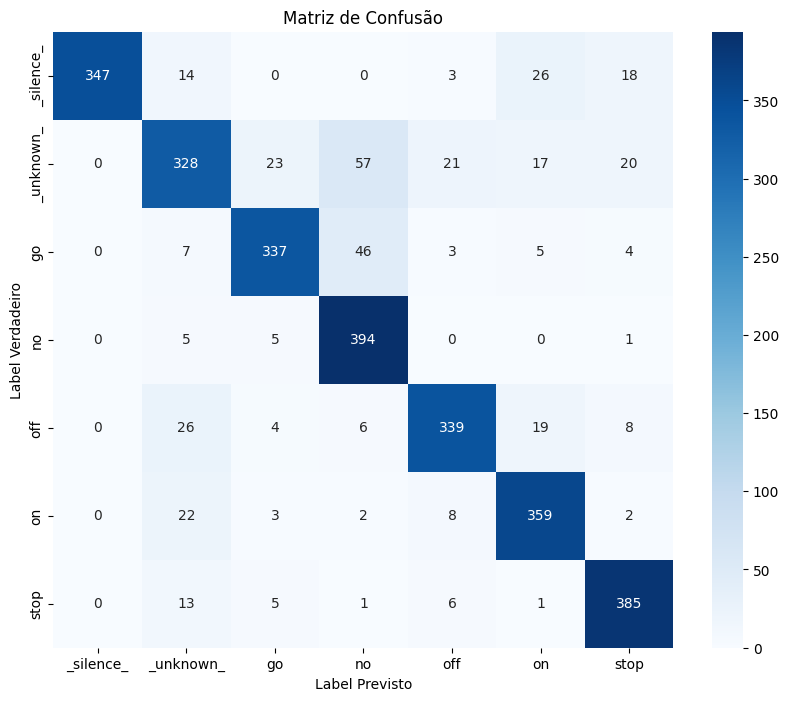

In [14]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()


## With Data Augmentation:

In [5]:
DATA_DIR = Path('../dataset_augmented')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'

CLASS_NAMES = np.array(sorted([item.name for item in TRAIN_DIR.glob('*') if item.is_dir()]))
print(f"Classes encontradas: {CLASS_NAMES}")

print("\nCriando o dataset de treinamento...")
train_ds = create_dataset(TRAIN_DIR, shuffle=True)

print("Criando o dataset de validação...")
val_ds = create_dataset(VALID_DIR, shuffle=False)

print("Criando o dataset de teste...")
test_ds = create_dataset(TEST_DIR, shuffle=False)

print("\n--- Verificação do Pipeline ---")
# <--- MUDANÇA: Atualizando variáveis e textos para MFCCs ---
for mfccs, labels in train_ds.take(1):
    print(f"Shape do lote de MFCCs: {mfccs.shape}")
    print(f"Shape do lote de labels: {labels.shape}")
    print(f"Tipo de dado dos MFCCs: {mfccs.dtype}")
    print(f"Tipo de dado dos labels: {labels.dtype}")
    
    first_mfcc = mfccs[0]
    print(f"Shape de um único MFCC: {first_mfcc.shape}")
    
    first_label = labels[0]
    print(f"Label do primeiro item do lote: {first_label.numpy()} ({CLASS_NAMES[first_label]})")


Classes encontradas: ['_silence_' '_unknown_' 'go' 'no' 'off' 'on' 'stop']

Criando o dataset de treinamento...


I0000 00:00:1758827585.703406   72636 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9444 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Criando o dataset de validação...
Criando o dataset de teste...

--- Verificação do Pipeline ---
Shape do lote de MFCCs: (32, 61, 40, 1)
Shape do lote de labels: (32,)
Tipo de dado dos MFCCs: <dtype: 'float32'>
Tipo de dado dos labels: <dtype: 'int64'>
Shape de um único MFCC: (61, 40, 1)
Label do primeiro item do lote: 0 (_silence_)


2025-09-25 16:13:06.600555: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-25 16:13:06.603609: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Formato (shape) do lote de MFCCs: (32, 61, 40, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-25 16:13:15.235904: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


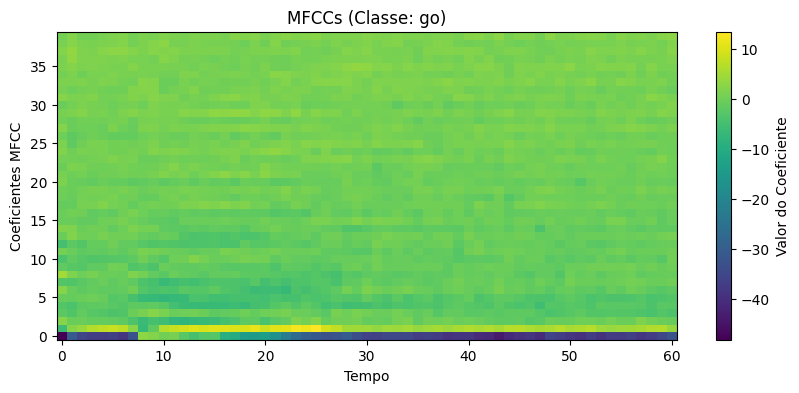

In [9]:
for mfccs, labels in train_ds.take(1):
    input_shape = mfccs.shape[1:]
    print(f"\nFormato (shape) do lote de MFCCs: {mfccs.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    # Não aplicamos mais o log aqui, pois os MFCCs já estão processados.
    plt.imshow(mfccs[0, :, :, 0].numpy().T, aspect='auto', origin='lower')
    plt.title(f"MFCCs (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Coeficientes MFCC")
    plt.xlabel("Tempo")
    plt.colorbar(label='Valor do Coeficiente')
    plt.show()
    break

### Training:

In [17]:
model_mfcc_aug = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax') # Usar len(CLASS_NAMES) é mais robusto
])

model_mfcc_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_6           │ (None, 61, 40, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 40, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 61, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 15, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 15, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 15, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,923 (4.94 MB)

 Trainable params: 1,293,641 (4.93 MB)

 Non-trainable params: 1,282 (5.01 KB)

In [18]:
model_mfcc_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [20]:
history = model_mfcc_aug.fit(train_ds, validation_data=val_ds, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8280 - loss: 0.4859 - val_accuracy: 0.9105 - val_loss: 0.2596
Epoch 2/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9252 - loss: 0.2188 - val_accuracy: 0.9321 - val_loss: 0.1989
Epoch 3/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9431 - loss: 0.1665 - val_accuracy: 0.9407 - val_loss: 0.1890
Epoch 4/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9542 - loss: 0.1329 - val_accuracy: 0.9369 - val_loss: 0.2060
Epoch 5/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9610 - loss: 0.1153 - val_accuracy: 0.9416 - val_loss: 0.1874
Epoch 6/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9651 - loss: 0.1020 - val_accuracy: 0.9429 - val_loss: 0.2071
Epoch 7/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9701 - loss: 0.0878 - val_accuracy: 0.9358 - val_loss: 0.2469
Epoch 8/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9744 - loss: 

### Testing:

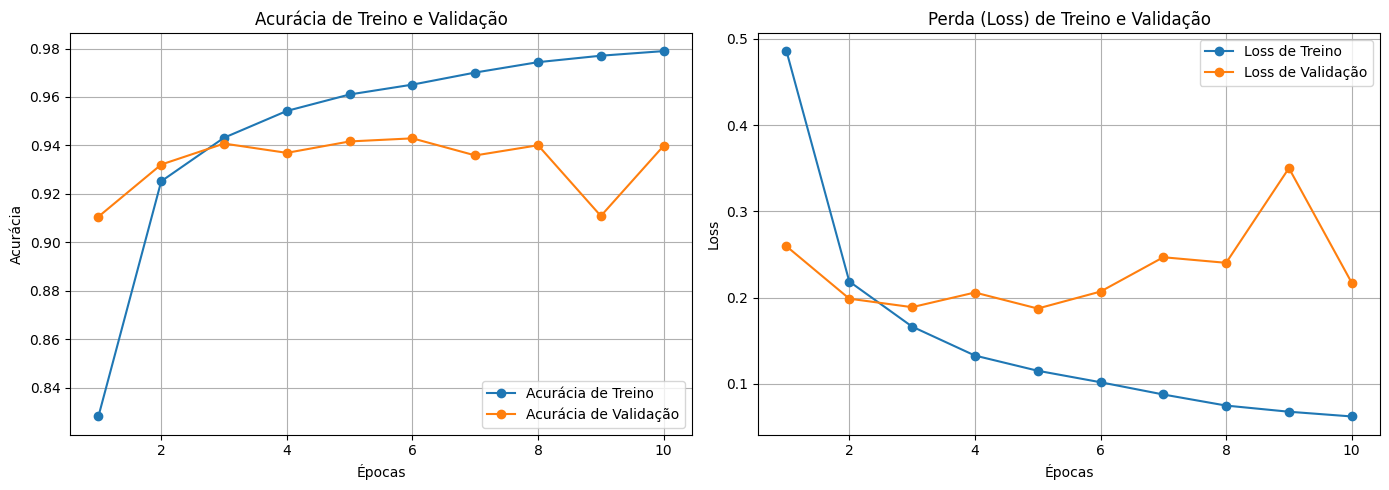

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [22]:
y_pred_probs = model_mfcc.predict(test_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       1.00      0.85      0.92       408
   _unknown_       0.80      0.74      0.77       466
          go       0.91      0.84      0.87       402
          no       0.79      0.97      0.87       405
         off       0.91      0.84      0.87       402
          on       0.83      0.91      0.87       396
        stop       0.88      0.94      0.91       411

    accuracy                           0.87      2890
   macro avg       0.87      0.87      0.87      2890
weighted avg       0.87      0.87      0.87      2890



2025-09-25 11:21:16.498578: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- Matriz de Confusão ---


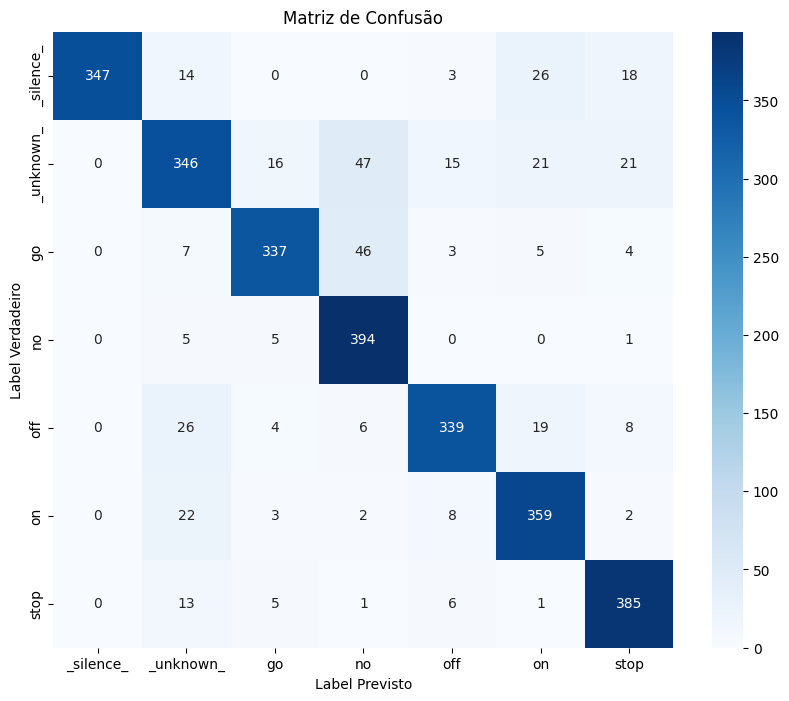

In [23]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()


In [24]:
model_mfcc_aug.save('../models/model_mfcc_aug.keras')

## Gerando modelo .tflite (float16):

In [25]:
keras_model = tf.keras.models.load_model("../models/model_mfcc_aug.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

print("\nIniciando conversão com quantização Float16...")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("../models/model_mfcc_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em ../models/model_mfcc_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmpxw1qzods/assets


INFO:tensorflow:Assets written to: /tmp/tmpxw1qzods/assets


Saved artifact at '/tmp/tmpxw1qzods'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 61, 40, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  127312089816176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089820576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089810896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089816000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089852640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089847008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089844720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089854576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089843488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312089849296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127312090107040

W0000 00:00:1758810077.393515   59397 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1758810077.393524   59397 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Modelo com Float16 Quantization salvo em ../models/model_mfcc_fp16.tflite


2025-09-25 11:21:17.393726: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxw1qzods
2025-09-25 11:21:17.394347: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-25 11:21:17.394350: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpxw1qzods
I0000 00:00:1758810077.401079   59397 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-09-25 11:21:17.402547: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-25 11:21:17.455524: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpxw1qzods
2025-09-25 11:21:17.467526: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 73802 microseconds.


## Testing .tflite model (float16):

In [26]:
TFLITE_MODEL_PATH = Path('../models/model_mfcc_fp16.tflite')

print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}") # Deve ser float32
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}") # Deve ser float32

Carregando modelo TFLite de: ../models/model_mfcc_fp16.tflite

--- Detalhes do Modelo TFLite ---
Entrada (Shape): [ 1 61 40  1]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 7]
Saída (Tipo): <class 'numpy.float32'>


/home/rolds/Documents/Projects/KeyWord Spotting Wonder/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/dev-env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [27]:
y_true = []
y_pred = []
total_samples = 0

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds:
    # Iterar sobre cada amostra no lote
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra de dado
        sample_data = data_batch[i]
        
        # Adicionar a dimensão do lote (batch dimension) para corresponder ao shape da entrada do modelo
        input_tensor = np.expand_dims(sample_data, axis=0).astype(np.float32)

        # Definir o tensor de entrada, executar inferência e obter a saída
        # Não precisamos de nenhuma conversão manual, o interpretador cuida de tudo.
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        
        # Armazenar o rótulo previsto e o rótulo verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...
Avaliadas 32 amostras...
Avaliadas 64 amostras...
Avaliadas 96 amostras...
Avaliadas 128 amostras...
Avaliadas 160 amostras...
Avaliadas 192 amostras...
Avaliadas 224 amostras...
Avaliadas 256 amostras...
Avaliadas 288 amostras...
Avaliadas 320 amostras...
Avaliadas 352 amostras...
Avaliadas 384 amostras...
Avaliadas 416 amostras...
Avaliadas 448 amostras...
Avaliadas 480 amostras...
Avaliadas 512 amostras...
Avaliadas 544 amostras...
Avaliadas 576 amostras...
Avaliadas 608 amostras...
Avaliadas 640 amostras...
Avaliadas 672 amostras...
Avaliadas 704 amostras...
Avaliadas 736 amostras...
Avaliadas 768 amostras...
Avaliadas 800 amostras...
Avaliadas 832 amostras...
Avaliadas 864 amostras...
Avaliadas 896 amostras...
Avaliadas 928 amostras...
Avaliadas 960 amostras...
Avaliadas 992 amostras...
Avaliadas 1024 amostras...
Avaliadas 1056 amostras...
Avaliadas 1088 amostras...
Avaliadas 1120 amostras...
Avaliadas 1152 amostras...
Avaliadas 1184 amos

In [28]:
print("\n--- Relatório de Classificação ---")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       1.00      0.91      0.96       408
   _unknown_       0.79      0.86      0.83       466
          go       0.81      0.95      0.87       402
          no       0.90      0.92      0.91       405
         off       0.95      0.90      0.92       402
          on       0.97      0.87      0.92       396
        stop       0.98      0.93      0.96       411

    accuracy                           0.91      2890
   macro avg       0.91      0.91      0.91      2890
weighted avg       0.91      0.91      0.91      2890




--- Matriz de Confusão ---


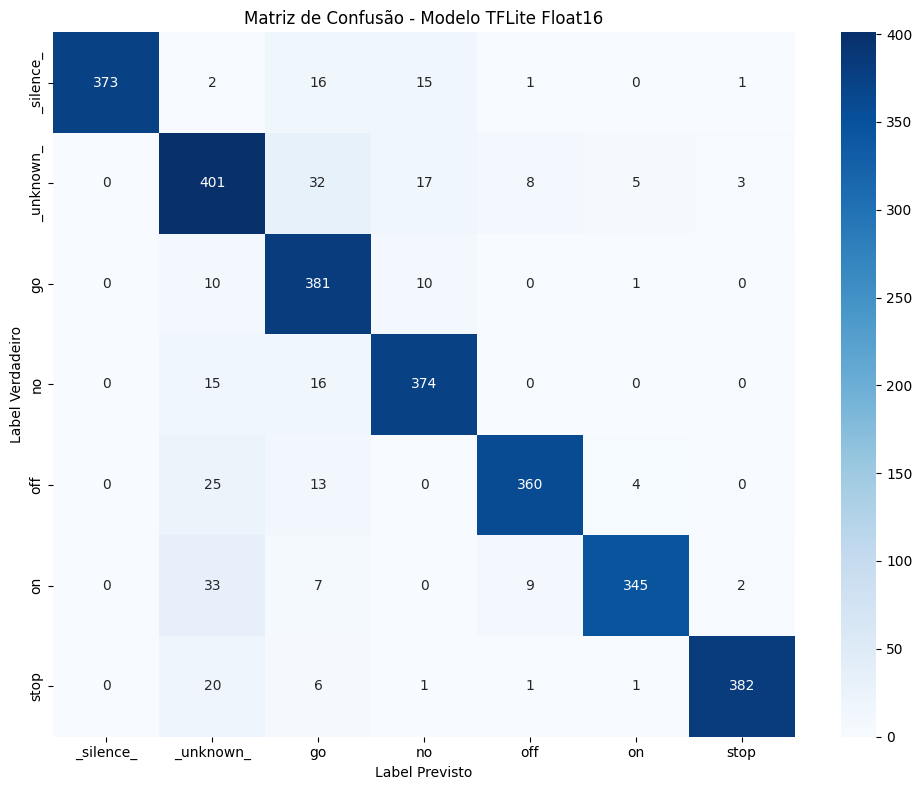

In [29]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()